In [10]:
# 1. Import the necessary Data Science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styles for plots
sns.set_theme(style="whitegrid")

# 2. Load the dataset
# Note: Ensure that 'customers-1000.csv' is saved in the exact same folder as this Jupyter Notebook file.
df = pd.read_csv('customers-1000.csv')

# 3. Display the first 5 rows to verify it loaded correctly
df.head()

,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website
0,1,dE014d010c7ab0c,Andrew,Goodman,Stewart-Flynn,Rowlandberg,Macao,846-790-4623x4715,(422)787-2331x71127,marieyates@gomez-spencer.info,2021-07-26,http://www.shea.biz/
1,2,2B54172c8b65eC3,Alvin,Lane,"Terry, Proctor and Lawrence",Bethside,Papua New Guinea,124-597-8652x05682,321.441.0588x6218,alexandra86@mccoy.com,2021-06-24,http://www.pena-cole.com/
2,3,d794Dd48988d2ac,Jenna,Harding,Bailey Group,Moniquemouth,China,(335)987-3085x3780,001-680-204-8312,justincurtis@pierce.org,2020-04-05,http://www.booth-reese.biz/
3,4,3b3Aa4aCc68f3Be,Fernando,Ford,Moss-Maxwell,Leeborough,Macao,(047)752-3122,048.779.5035x9122,adeleon@hubbard.org,2020-11-29,http://www.hebert.com/
4,5,D60df62ad2ae41E,Kara,Woods,Mccarthy-Kelley,Port Jacksonland,Nepal,+1-360-693-4419x19272,163-627-2565,jesus90@roberson.info,2022-04-22,http://merritt.com/


In [2]:
# Check the data types of each column and memory usage
print("--- Data Info ---")
df.info()

# Count exactly how many missing (null) values are in each column
print("\n--- Missing Values ---")
df.isnull().sum()

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Index              1000 non-null   int64 
 1   Customer Id        1000 non-null   object
 2   First Name         1000 non-null   object
 3   Last Name          1000 non-null   object
 4   Company            1000 non-null   object
 5   City               1000 non-null   object
 6   Country            1000 non-null   object
 7   Phone 1            1000 non-null   object
 8   Phone 2            1000 non-null   object
 9   Email              1000 non-null   object
 10  Subscription Date  1000 non-null   object
 11  Website            1000 non-null   object
dtypes: int64(1), object(11)
memory usage: 93.9+ KB

--- Missing Values ---


Index                0
Customer Id          0
First Name           0
Last Name            0
Company              0
City                 0
Country              0
Phone 1              0
Phone 2              0
Email                0
Subscription Date    0
Website              0
dtype: int64

In [3]:
# Generate descriptive statistics for all columns
df.describe(include='all')

,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website
count,1000.000000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,NaN,1000,536,622,992,983,240,1000,1000,1000,608,973
top,NaN,dE014d010c7ab0c,Larry,Waters,Benitez LLC,Jacobmouth,Liechtenstein,846-790-4623x4715,(422)787-2331x71127,marieyates@gomez-spencer.info,2020-07-17,http://www.tapia.com/
freq,NaN,1,6,7,2,2,12,1,1,1,5,3
mean,500.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,288.819436,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,250.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,500.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,750.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Convert 'Subscription Date' to actual datetime objects
df['Subscription Date'] = pd.to_datetime(df['Subscription Date'])

# Create a new column just for the 'Year' to make grouping easier later
df['Subscription Year'] = df['Subscription Date'].dt.year

# Show the updated dataframe
df.head()

,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website,Subscription Year
0,1,dE014d010c7ab0c,Andrew,Goodman,Stewart-Flynn,Rowlandberg,Macao,846-790-4623x4715,(422)787-2331x71127,marieyates@gomez-spencer.info,2021-07-26,http://www.shea.biz/,2021
1,2,2B54172c8b65eC3,Alvin,Lane,"Terry, Proctor and Lawrence",Bethside,Papua New Guinea,124-597-8652x05682,321.441.0588x6218,alexandra86@mccoy.com,2021-06-24,http://www.pena-cole.com/,2021
2,3,d794Dd48988d2ac,Jenna,Harding,Bailey Group,Moniquemouth,China,(335)987-3085x3780,001-680-204-8312,justincurtis@pierce.org,2020-04-05,http://www.booth-reese.biz/,2020
3,4,3b3Aa4aCc68f3Be,Fernando,Ford,Moss-Maxwell,Leeborough,Macao,(047)752-3122,048.779.5035x9122,adeleon@hubbard.org,2020-11-29,http://www.hebert.com/,2020
4,5,D60df62ad2ae41E,Kara,Woods,Mccarthy-Kelley,Port Jacksonland,Nepal,+1-360-693-4419x19272,163-627-2565,jesus90@roberson.info,2022-04-22,http://merritt.com/,2022


In [5]:
# Check for any duplicate rows in the dataset
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates}")

# If there were duplicates, we would use df.drop_duplicates(inplace=True)

Number of duplicate rows found: 0


/var/folders/b4/8pqxh51x36l1mzkf61g7840r0000gn/T/ipykernel_99642/354235138.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


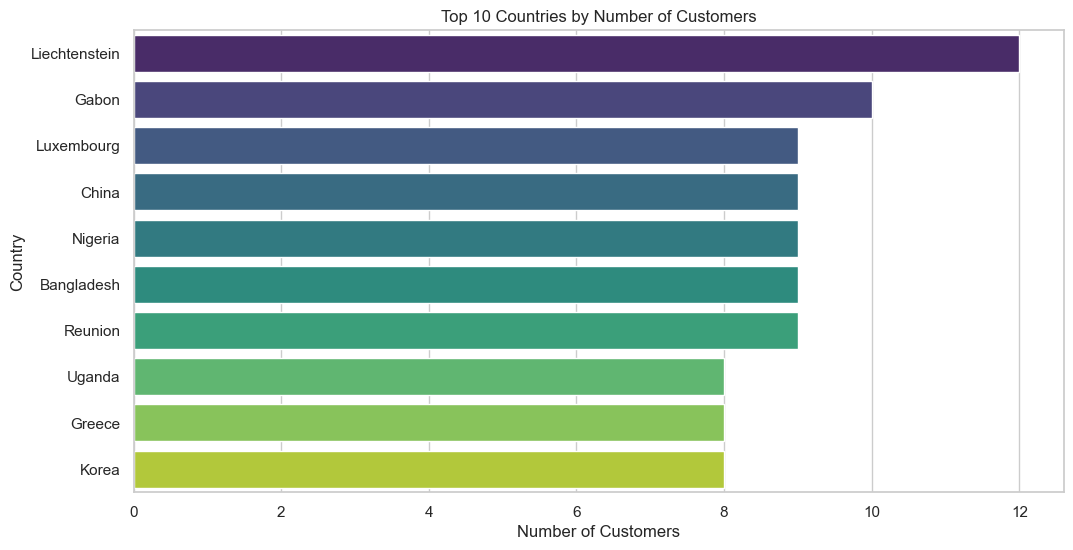

In [11]:
# Count the number of customers per country
top_countries = df['Country'].value_counts().head(10)

# Create a bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')

plt.title('Top 10 Countries by Number of Customers')
plt.xlabel('Number of Customers')
plt.ylabel('Country')
plt.show()

# --- Interpretation ---
# This bar chart shows that the customer base is globally distributed. 
# [Insert the name of the top country] has the highest concentration of customers.

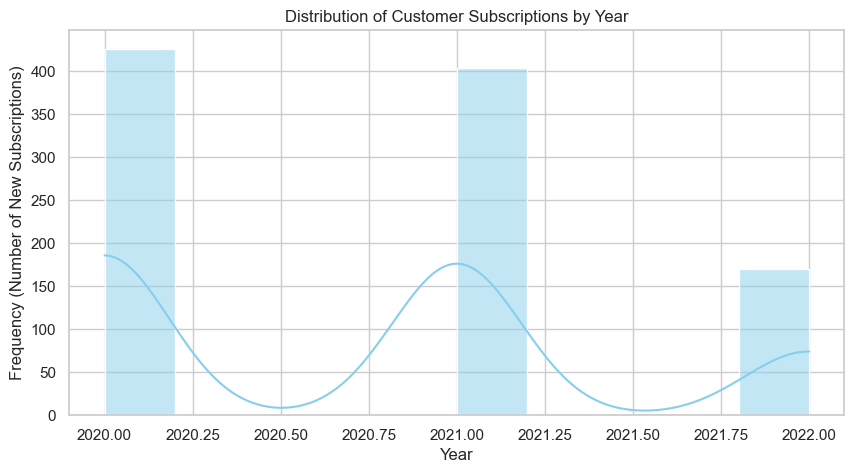

In [7]:
# Create a histogram of the Subscription Year
plt.figure(figsize=(10, 5))
sns.histplot(df['Subscription Year'], bins=10, kde=True, color='skyblue')

plt.title('Distribution of Customer Subscriptions by Year')
plt.xlabel('Year')
plt.ylabel('Frequency (Number of New Subscriptions)')
plt.show()

# --- Interpretation ---
# The histogram reveals the growth trend of the company. 
# We can see a peak in subscriptions during the year [Insert Year].

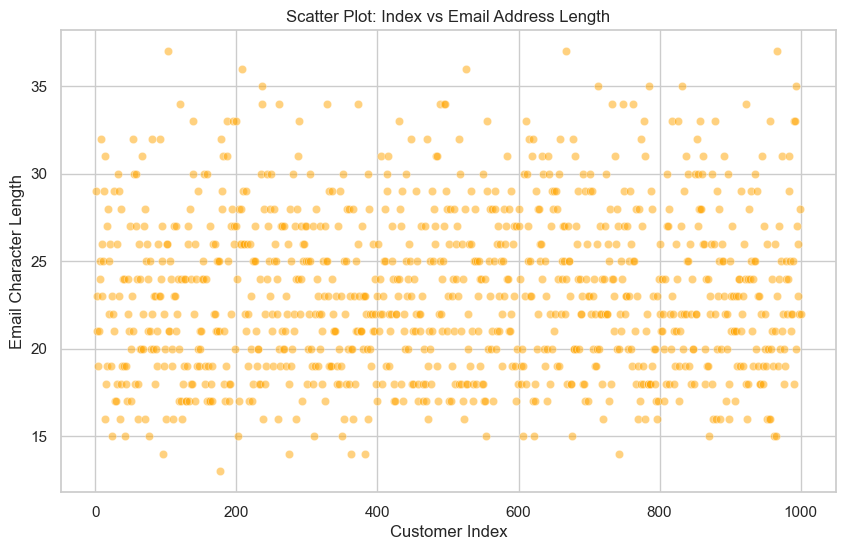

In [8]:
# Create a numeric feature for visualization
df['Email Length'] = df['Email'].apply(len)

# Create a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Index', y='Email Length', data=df, alpha=0.5, color='orange')

plt.title('Scatter Plot: Index vs Email Address Length')
plt.xlabel('Customer Index')
plt.ylabel('Email Character Length')
plt.show()

# --- Interpretation ---
# The scatter plot shows the distribution of email lengths across the dataset. 
# Most email lengths fall between [Insert Range] characters, with no significant correlation to the Index.

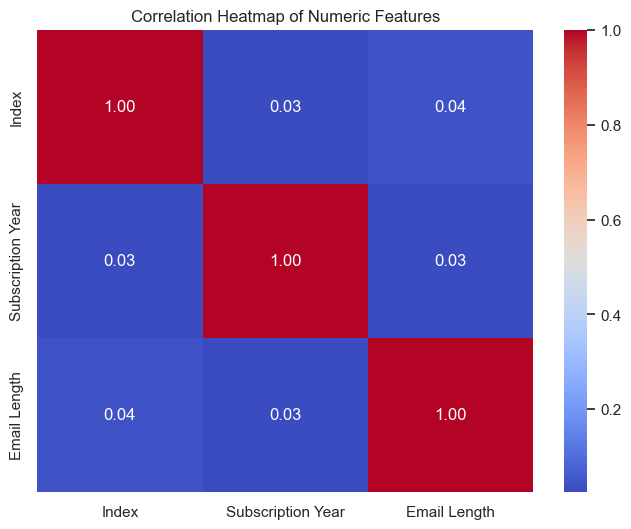

In [9]:
# Select numeric columns for the correlation matrix
numeric_df = df.select_dtypes(include=[np.number])

# Calculate correlation
corr = numeric_df.corr()

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Heatmap of Numeric Features')
plt.show()

# --- Interpretation ---
# The heatmap shows the correlation coefficients between numeric variables. 
# Values close to 1 or -1 indicate strong relationships, while values near 0 show no relationship.